# Лабораторная работа №2
## Задачи регрессии и классификации. Линейные модели: линейная и логистическая регрессии
**Датасет:** Stroke Prediction Dataset (исходный файл `stroke_data.csv`)  
**Цели работы:**
1. Подготовить конвейер обработки данных без утечки информации (Data Leakage).
2. Построить и исследовать модель множественной линейной регрессии для непрерывного числового признака.
3. Оценить метрики качества регрессии (MSE, RMSE, MAE, R²) и применить методы улучшения (полиномиальные признаки, Ridge/Lasso регуляризация).
4. Построить и исследовать модель логистической регрессии для задачи бинарной классификации.
5. Оценить качество классификатора в условиях сильного дисбаланса классов (Confusion Matrix, Precision, Recall, F1-score) и устранить дисбаланс.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки для красивых графиков и таблиц
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [4]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки для красивых графиков и таблиц
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## 1. Загрузка исходного датасета и подготовка признаков
Используем исходный (неотредактированный) файл `stroke_data.csv`.  
Проводим очистку, устраняем пропуски и кодируем категориальные переменные без утечки данных (Data Leakage).

In [6]:
# Загрузка исходного сырого датасета
df_raw = pd.read_csv('stroke_data.csv')

# Удаляем неинформативный признак id
df = df_raw.drop(columns=['id'])

# Заполняем пропуски правильными статистиками
df['smoking_status'] = df['smoking_status'].replace('Unknown', np.nan)
df['smoking_status'] = df['smoking_status'].fillna(df['smoking_status'].mode()[0])
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# One-Hot Encoding для категориальных столбцов (с drop_first=True против переобучения)
cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

print(f"Размерность подготовленного датасета: {df.shape}")
df.head()

Размерность подготовленного датасета: (5110, 16)


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,1,0,1,0,1,0,0,1,0,0
1,61.0,0,0,202.21,28.1,1,0,0,1,0,0,1,0,0,1,0
2,80.0,0,1,105.92,32.5,1,1,0,1,0,1,0,0,0,1,0
3,49.0,0,0,171.23,34.4,1,0,0,1,0,1,0,0,1,0,1
4,79.0,1,0,174.12,24.0,1,0,0,1,0,0,1,0,0,1,0


## 2. Задача регрессии: предсказание уровня глюкозы (`avg_glucose_level`)
* **Целевая переменная ($y$):** `avg_glucose_level` (непрерывный числовой показатель).
* **Матрица признаков ($X$):** все остальные признаки (возраст, гипертония, болезни сердца, ИМТ, пол, работа и т.д.), исключая целевой признак классификации `stroke`.
* **Масштабирование:** применяется `StandardScaler` строго после разделения выборки, чтобы исключить утечку данных из теста в обучение.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Формируем матрицу признаков X и целевой вектор y
# Исключаем целевой признак регрессии и признак классификации 'stroke'
X = df.drop(columns=['avg_glucose_level', 'stroke'])
y = df['avg_glucose_level']

# 2. Разделяем выборку: 80% на обучение, 20% на контроль (random_state для воспроизводимости)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Масштабируем числовые признаки БЕЗ утечки данных:
scaler = StandardScaler()
# На train вычисляем параметры и трансформируем:
X_train_scaled = scaler.fit_transform(X_train)
# На test только применяем параметры train:
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка X_train: {X_train_scaled.shape}, y_train: {y_train.shape}")
print(f"Тестовая выборка X_test: {X_test_scaled.shape}, y_test: {y_test.shape}")

Обучающая выборка X_train: (4088, 14), y_train: (4088,)
Тестовая выборка X_test: (1022, 14), y_test: (1022,)


## 3. Обучение базовой модели множественной линейной регрессии
Обучаем модель `LinearRegression` методом наименьших квадратов (МНК).  
Исследуем полученные веса модели ($w_i$) и свободный член ($w_0$) для оценки влияния признаков на уровень глюкозы.

In [8]:
from sklearn.linear_model import LinearRegression

# 1. Создаем объект линейной регрессии
linear_model = LinearRegression()

# 2. Обучаем модель на стандартизированных обучающих данных
linear_model.fit(X_train_scaled, y_train)

# 3. Выводим свободный член w0 (смещение)
print(f"Свободный член (Intercept, w0): {linear_model.intercept_:.2f}")

# 4. Формируем наглядную таблицу весов каждого признака
weights_df = pd.DataFrame({
    'Признак': X.columns,
    'Вес (w_i)': linear_model.coef_
}).sort_values(by='Вес (w_i)', ascending=False)

print("\nВлияние признаков на прогнозируемый уровень глюкозы (от наибольшего к наименьшему):")
weights_df.reset_index(drop=True)

Свободный член (Intercept, w0): 106.45

Влияние признаков на прогнозируемый уровень глюкозы (от наибольшего к наименьшему):


,Признак,Вес (w_i)
0,age,9.642552e+00
1,bmi,5.577113e+00
2,work_type_children,5.457942e+00
3,hypertension,5.206119e+00
4,heart_disease,4.095558e+00
5,gender_Male,2.269558e+00
6,work_type_Private,1.053156e+00
7,work_type_Never_worked,6.050608e-01
8,ever_married_Yes,5.447844e-01
9,work_type_Self-employed,1.812636e-01


## 4. Оценка качества регрессионной модели
Для оценки ошибки прогноза на тестовых данных ($X_{test}$) используем метрики из методички (стр. 8):
* **MAE** (Mean Absolute Error) — средняя абсолютная ошибка: показывает, на сколько единиц в среднем ошибается модель.
* **MSE** (Mean Squared Error) — среднеквадратичная ошибка: сильнее штрафует за крупные промахи.
* **RMSE** (Root Mean Squared Error) — корень из MSE: ошибка в реальных единицах измерения (мг/дл).
* **R²** (Коэффициент детерминации) — показывает долю дисперсии зависимой переменной, объясненную моделью (в диапазоне от $-\infty$ до $1$).

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Получаем прогнозы модели для тестовой выборки
y_pred_test = linear_model.predict(X_test_scaled)

# 2. Вычисляем метрики качества
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse) # Корень из MSE (в единицах целевой переменной)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("=== Результаты базовой линейной регрессии ===")
print(f"MAE (Средняя абсолютная ошибка): {mae:.2f} мг/дл")
print(f"MSE (Среднеквадратичная ошибка): {mse:.2f}")
print(f"RMSE (Корень из MSE):            {rmse:.2f} мг/дл")
print(f"R² (Коэффициент детерминации):    {r2:.4f}")

# Сравнение: средний разброс реального сахара в тесте
print(f"\nСреднее значение сахара в тесте: {y_test.mean():.2f}")
print(f"Стандартное отклонение сахара:   {y_test.std():.2f}")

=== Результаты базовой линейной регрессии ===
MAE (Средняя абсолютная ошибка): 31.84 мг/дл
MSE (Среднеквадратичная ошибка): 1787.56
RMSE (Корень из MSE):            42.28 мг/дл
R² (Коэффициент детерминации):    0.0704

Среднее значение сахара в тесте: 104.92
Стандартное отклонение сахара:   43.87


## 5. Улучшение регрессионной модели: Полиномиальные признаки и Регуляризация (L1/L2)
Базовая линейная регрессия показала невысокий коэффициент детерминации ($R^2 \approx 0.07$), так как реальная зависимость нелинейна.
Для улучшения модели (методичка, стр. 8–12):
1. **Расширим признаковое пространство** с помощью `PolynomialFeatures(degree=2)`: добавим нелинейные эффекты и взаимодействия признаков.
2. **Применим регуляризацию**, чтобы избежать переобучения из-за резкого роста числа признаков:
   * **Ridge ($L_2$-регуляризация)**: штрафует сумму квадратов весов ($\lambda \sum w_i^2$), сжимая их к нулю;
   * **Lasso ($L_1$-регуляризация)**: штрафует сумму модулей весов ($\lambda \sum |w_i|$), обнуляя неинформативные признаки.

In [10]:
from sklearn.preprocessing import PolynomialFeatures

# Создаем полиномиальные признаки 2-й степени (квадраты и попарные произведения)
poly = PolynomialFeatures(degree=2, include_bias=False)

# Обучаем полином на обучающей выборке и трансформируем обе выборки
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f"Было признаков:  {X_train_scaled.shape[1]}")
print(f"Стало признаков: {X_train_poly.shape[1]} (признаковое пространство расширено в {X_train_poly.shape[1] // X_train_scaled.shape[1]} раз!)")

Было признаков:  14
Стало признаков: 119 (признаковое пространство расширено в 8 раз!)


In [11]:
from sklearn.linear_model import Ridge, Lasso

# 1. Полиномиальная регрессия без регуляризации
poly_linear = LinearRegression()
poly_linear.fit(X_train_poly, y_train)
y_pred_poly = poly_linear.predict(X_test_poly)

# 2. L2-регуляризация (Ridge)
ridge_model = Ridge(alpha=50.0) # alpha — коэффициент штрафа (lambda в формуле)
ridge_model.fit(X_train_poly, y_train)
y_pred_ridge = ridge_model.predict(X_test_poly)

# 3. L1-регуляризация (Lasso)
lasso_model = Lasso(alpha=0.5)
lasso_model.fit(X_train_poly, y_train)
y_pred_lasso = lasso_model.predict(X_test_poly)

# 4. Сводная таблица результатов для сравнения
comparison_df = pd.DataFrame({
    'Модель': [
        'Базовая LinearRegression',
        'Полиномиальная (degree=2)',
        'Полиномиальная + Ridge (L2)',
        'Полиномиальная + Lasso (L1)'
    ],
    'MAE (мг/дл)': [
        mae,
        mean_absolute_error(y_test, y_pred_poly),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso)
    ],
    'RMSE (мг/дл)': [
        rmse,
        np.sqrt(mean_squared_error(y_test, y_pred_poly)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    ],
    'R² score': [
        r2,
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
})

print("=== Сводное сравнение регрессионных моделей ===")
comparison_df.round(4)

=== Сводное сравнение регрессионных моделей ===


,Модель,MAE (мг/дл),RMSE (мг/дл),R² score
0,Базовая LinearRegression,31.8365,42.2796,0.0704
1,Полиномиальная (degree=2),31.3393,42.1565,0.0758
2,Полиномиальная + Ridge (L2),31.3083,42.1362,0.0767
3,Полиномиальная + Lasso (L1),31.3240,42.0572,0.0801


In [12]:
# Сколько коэффициентов Lasso обнулил (выкинул как бесполезные)?
zero_weights = np.sum(lasso_model.coef_ == 0)
total_weights = len(lasso_model.coef_)

print(f"Lasso занулил {zero_weights} из {total_weights} признаков!")
print(f"Осталось активных информативных признаков: {total_weights - zero_weights}")

Lasso занулил 91 из 119 признаков!
Осталось активных информативных признаков: 28


## 6. Задача бинарной классификации: прогнозирование инсульта (`stroke`)
* **Целевая переменная ($y$):** `stroke` (1 — наличие инсульта, 0 — отсутствие).
* **Модель:** `LogisticRegression` (сигмоидная функция активации, оптимизация функции потерь LogLoss методом максимального правдоподобия).
* **Особенность датасета:** сильный дисбаланс классов (пациентов с инсультом всего около 5%).

In [13]:
from sklearn.linear_model import LogisticRegression

# 1. Формируем X и y для классификации
X_clf = df.drop(columns=['stroke'])
y_clf = df['stroke']

# 2. Разделяем на Train и Test со стратификацией (stratify сохраняет пропорцию классов 0 и 1)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# 3. Масштабируем признаки X
scaler_clf = StandardScaler()
X_train_c_scaled = scaler_clf.fit_transform(X_train_c)
X_test_c_scaled = scaler_clf.transform(X_test_c)

# 4. Обучаем базовую логистическую регрессию
logreg_base = LogisticRegression(random_state=42)
logreg_base.fit(X_train_c_scaled, y_train_c)

# Получаем предсказания классов и вероятностей
y_pred_base = logreg_base.predict(X_test_c_scaled)

## 7. Оценка базового классификатора и анализ «парадокса точности»
По методичке (стр. 18–21) в условиях дисбаланса классов метрика `Accuracy` обманчива:
* **True Positive (TP)** — больной верно определен как больной;
* **False Positive (FP)** — здоровый ошибочно назван больным (ложная тревога);
* **False Negative (FN)** — **самая опасная ошибка в медицине:** больной определен как здоровый!
* **Recall (Полнота)** = $\frac{TP}{TP + FN}$ — какую долю реальных инсультов нашла модель.
* **Precision (Точность)** = $\frac{TP}{TP + FP}$ — сколько из предсказанных инсультов были реальными.

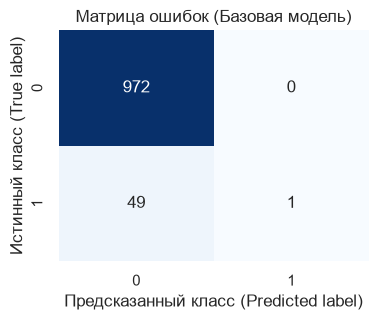

Общая точность (Accuracy): 0.9521

Отчет о классификации (Classification Report):
              precision    recall  f1-score   support

  Здоров (0)       0.95      1.00      0.98       972
 Инсульт (1)       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022



In [14]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Считаем матрицу ошибок
cm_base = confusion_matrix(y_test_c, y_pred_base)

# 2. Строим тепловую карту (Heatmap) по методичке (стр. 20)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Матрица ошибок (Базовая модель)')
plt.ylabel('Истинный класс (True label)')
plt.xlabel('Предсказанный класс (Predicted label)')
plt.show()

# 3. Комплексный отчет по метрикам
print(f"Общая точность (Accuracy): {accuracy_score(y_test_c, y_pred_base):.4f}")
print("\nОтчет о классификации (Classification Report):")
print(classification_report(y_test_c, y_pred_base, target_names=['Здоров (0)', 'Инсульт (1)'], zero_division=0))

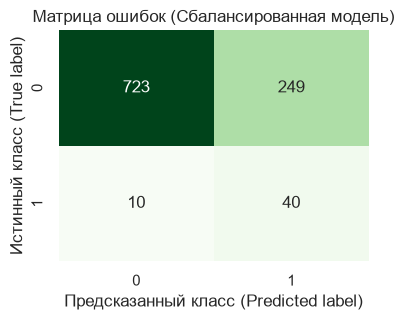

Отчет улучшенной модели (class_weight='balanced'):
              precision    recall  f1-score   support

  Здоров (0)       0.99      0.74      0.85       972
 Инсульт (1)       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



In [15]:
# Обучаем логистическую регрессию с автоматической балансировкой весов классов
# Модель будет жестче штрафоваться за пропуск редкого класса 1
logreg_balanced = LogisticRegression(class_weight='balanced', random_state=42)
logreg_balanced.fit(X_train_c_scaled, y_train_c)

y_pred_balanced = logreg_balanced.predict(X_test_c_scaled)
cm_balanced = confusion_matrix(y_test_c, y_pred_balanced)

# Рисуем матрицу ошибок улучшенной модели
plt.figure(figsize=(4, 3))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Матрица ошибок (Сбалансированная модель)')
plt.ylabel('Истинный класс (True label)')
plt.xlabel('Предсказанный класс (Predicted label)')
plt.show()

print("Отчет улучшенной модели (class_weight='balanced'):")
print(classification_report(y_test_c, y_pred_balanced, target_names=['Здоров (0)', 'Инсульт (1)']))